**PROJECT TEAM ID**: PTID-CDS-DEC-25-3516    

**PROJECT CODE** :PRCP-1016-HeartDieseasePred
    
**PROJECT NAME** : Heart Disease Prediction

# Heart Diesease Prediction
### PRCP-1016 Capstone Project

**Domain:** Healthcare

**Objective:** predicts whether a person has heart disease based on medical data.

##  1. Business Case



* Cardiovascular diseases are one of the leading causes of death worldwide.Early prediction of heart disease can help hospitals and doctors take preventive actions and save lives.

**Objective:**
To build a machine learning model that predicts whether a person has heart disease based on medical data.

## 2. Domain Analysis
**Domain: Healthcare**

**Problem Type: Binary Classification**

### Dataset Description

**Number of Features: 14 features + 1 target variable**

**patient_id**: Unique ID for each patient

**Numerical Features**

**age**: Age of the patient in years
    
**resting_blood_pressure**:Resting blood pressure (mm Hg)
    
**serum_cholesterol_mg_per_dl**:Serum cholesterol level (mg/dl)
    
**max_heart_rate_achieved**: Maximum heart rate achieved during exercise
    
**oldpeak_eq_st_depression**:ST depression induced by exercise relative to rest
    
**num_major_vessels**:Number of major vessels colored by fluoroscopy (0–3)

**Categorical Features**

**sex**: Gender (1 = Male, 0 = Female)
    
**chest_pain_type**:Type of chest pain (1–4)
    
**fasting_blood_sugar_gt_120_mg_per_dl**:Fasting blood sugar > 120 mg/dl (1 = True, 0 = False)
    
**resting_ekg_results**:Resting electrocardiographic results (0–2)
    
**exercise_induced_angina**:Exercise-induced angina (1 = Yes, 0 = No)
    
**slope_of_peak_exercise_st_segment**: Slope of the peak exercise ST segment (1–3)
    
**thal**:Thalassemia (3 = Normal, 6 = Fixed defect, 7 = Reversible defect)

**Target Variable**

**heart_disease**:Presence of heart disease (0 = No, 1 = Yes)

# Tasks Overview

* Task 1: Exploratory Data Analysis (EDA) & Data Understanding

* Task 2: Feature Engineering, Model Building & Evaluation

* Task 3: Business Insights & Hospital Recommendations

# Task 1: Data Analysis & EDA

### **This section explores the data to understand patient details and risk factors related to heart disease. It helps identify patterns, detect unusual values, and gain medical insights before building prediction models.**

**IMPORT LIBRARIES**

In [91]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    roc_curve, auc
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')


**Load Dataset**

In [39]:
values = pd.read_csv('values.csv')

In [40]:
labels = pd.read_csv('labels.csv')

In [41]:
values.head()

,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0


In [42]:
labels.head()

,patient_id,heart_disease_present
0,0z64un,0
1,ryoo3j,0
2,yt1s1x,1
3,l2xjde,1
4,oyt4ek,0


**Merge Dataset**

In [43]:
df = pd.merge(values,labels,on="patient_id")

In [44]:
df

,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0,1
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,5qfar3,2,reversible_defect,125,4,2,1,0,254,0.2,1,67,163,0,1
176,2s2b1f,2,normal,180,4,0,0,1,327,3.4,0,55,117,1,1
177,nsd00i,2,reversible_defect,125,3,0,0,0,309,1.8,1,64,131,1,1
178,0xw93k,1,normal,124,3,2,1,0,255,0.0,1,48,175,0,0


**Basic Checks**

In [45]:
df.shape

(180, 15)

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 15 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   patient_id                            180 non-null    object 
 1   slope_of_peak_exercise_st_segment     180 non-null    int64  
 2   thal                                  180 non-null    object 
 3   resting_blood_pressure                180 non-null    int64  
 4   chest_pain_type                       180 non-null    int64  
 5   num_major_vessels                     180 non-null    int64  
 6   fasting_blood_sugar_gt_120_mg_per_dl  180 non-null    int64  
 7   resting_ekg_results                   180 non-null    int64  
 8   serum_cholesterol_mg_per_dl           180 non-null    int64  
 9   oldpeak_eq_st_depression              180 non-null    float64
 10  sex                                   180 non-null    int64  
 11  age                

**Cheak Missing values**


In [47]:
df.isnull().sum()

,0
patient_id,0
slope_of_peak_exercise_st_segment,0
thal,0
resting_blood_pressure,0
chest_pain_type,0
num_major_vessels,0
fasting_blood_sugar_gt_120_mg_per_dl,0
resting_ekg_results,0
serum_cholesterol_mg_per_dl,0
oldpeak_eq_st_depression,0


**Dataset is clean (no missing values)**

In [48]:
df.duplicated().sum() # no duplicate rows


np.int64(0)

In [49]:
df['patient_id'].nunique() #counts the number of unique values in that column.

180

In [50]:
df.describe()

,slope_of_peak_exercise_st_segment,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,1.550000,131.311111,3.155556,0.694444,0.161111,1.050000,249.211111,1.010000,0.688889,54.811111,149.483333,0.316667,0.444444
std,0.618838,17.010443,0.938454,0.969347,0.368659,0.998742,52.717969,1.121357,0.464239,9.334737,22.063513,0.466474,0.498290
min,1.000000,94.000000,1.000000,0.000000,0.000000,0.000000,126.000000,0.000000,0.000000,29.000000,96.000000,0.000000,0.000000
25%,1.000000,120.000000,3.000000,0.000000,0.000000,0.000000,213.750000,0.000000,0.000000,48.000000,132.000000,0.000000,0.000000
50%,1.000000,130.000000,3.000000,0.000000,0.000000,2.000000,245.500000,0.800000,1.000000,55.000000,152.000000,0.000000,0.000000
75%,2.000000,140.000000,4.000000,1.000000,0.000000,2.000000,281.250000,1.600000,1.000000,62.000000,166.250000,1.000000,1.000000
max,3.000000,180.000000,4.000000,3.000000,1.000000,2.000000,564.000000,6.200000,1.000000,77.000000,202.000000,1.000000,1.000000


In [51]:
df.describe(include='O') #Statistical summary of all categorical (object/string) columns

,patient_id,thal
count,180,180
unique,180,3
top,0z64un,normal
freq,1,98


**Target Variable Distribution**

In [52]:
df['heart_disease_present'].value_counts()

,count
heart_disease_present,
0,100
1,80


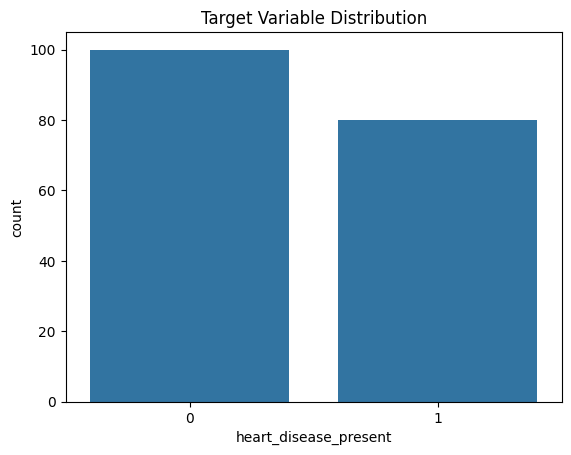

In [53]:
sns.countplot(x='heart_disease_present', data=df)
plt.title('Target Variable Distribution')
plt.show()


**EDA**

**Univariate Analysis**

**Age**




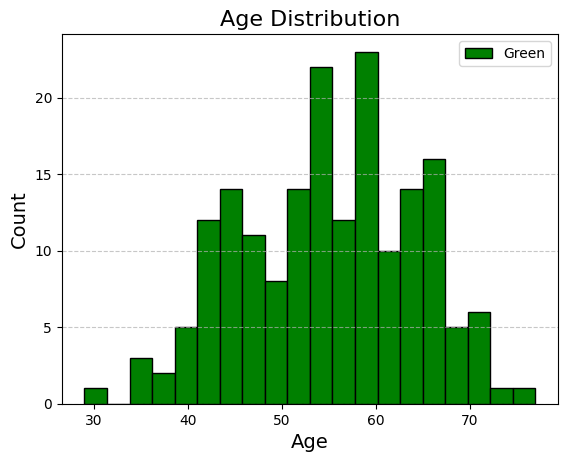

In [54]:
import matplotlib.pyplot as plt

plt.hist(df['age'], bins=20, color='green', edgecolor='black', label='Green')
plt.title('Age Distribution', fontsize=16)
plt.xlabel('Age', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()  # This will show "Green" in the plot
plt.show()


**Most patients are between 45–65 years.**

**Highest number of patients are around 55–60 years.**

**Very few patients are below 35 years.**

**Patient count decreases after 70 years.**

**Age is an important feature for heart disease prediction.**

**Resting Blood Pressure**

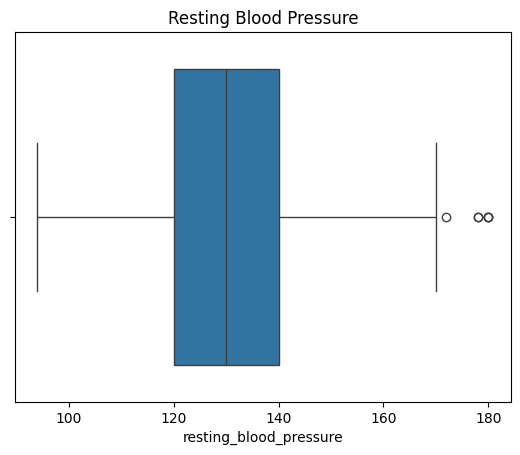

In [55]:
sns.boxplot(x=df['resting_blood_pressure'])
plt.title('Resting Blood Pressure')
plt.show()


**Most patients have resting BP between 120–140 mmHg.**

**Median BP is around 130 mmHg**

**A few high BP outliers (170–180 mmHg) are present.**

**Very few patients have low BP (<100 mmHg).**

**Resting blood pressure is an important risk factor for heart disease.**

**Cholesterol**

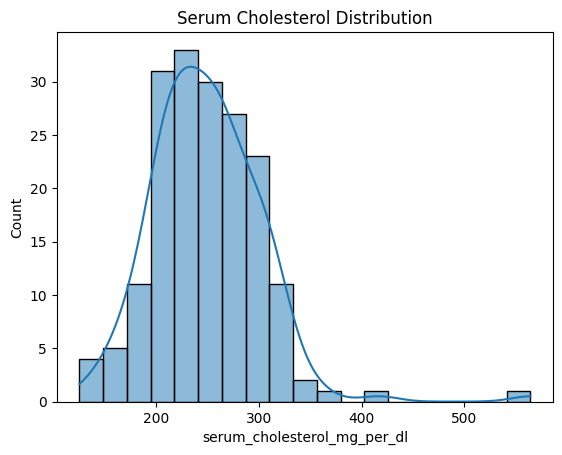

In [56]:
sns.histplot(df['serum_cholesterol_mg_per_dl'], kde=True)
plt.title('Serum Cholesterol Distribution')
plt.show()


**Most patients have cholesterol between 200–300 mg/dL.**

**Peak values are around 220–250 mg/dL.**

**Distribution is right-skewed.**

**A few very high outliers (>400 mg/dL) exist.**

**Serum cholesterol is an important risk factor for heart disease.**

**Max Heart Rate**

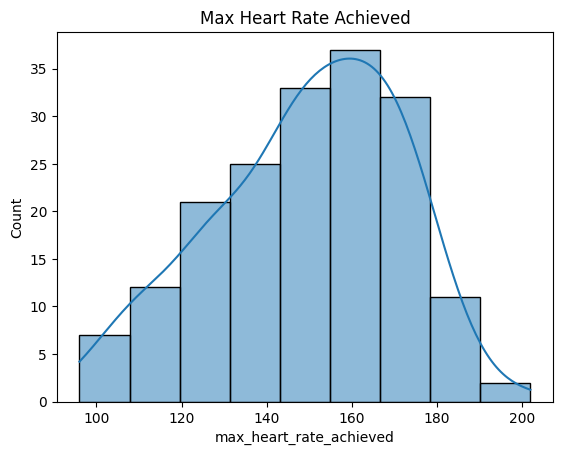

In [57]:
sns.histplot(df['max_heart_rate_achieved'], kde=True)
plt.title('Max Heart Rate Achieved')
plt.show()


**Most patients have max heart rate between 140–170 bpm.**

**Peak values are around 155–165 bpm.**

**Few patients show low max heart rate (<120 bpm).**

**Very few patients reach 180–200 bpm**

**Max heart rate is an important feature for heart disease prediction.**

**Bivariate Analysis**

**Sex vs Heart Disease**

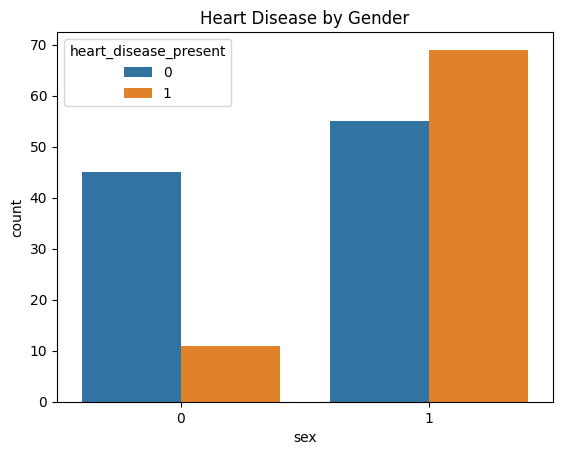

In [58]:
sns.countplot(x='sex', hue='heart_disease_present', data=df)
plt.title('Heart Disease by Gender')
plt.show()


**Males(sex = 1) have more heart disease cases than females.**

**Females(sex = 0) mostly show no heart disease.**

**Gender is an important predictor of heart disease.**

**Chest Pain Type vs Heart Disease**









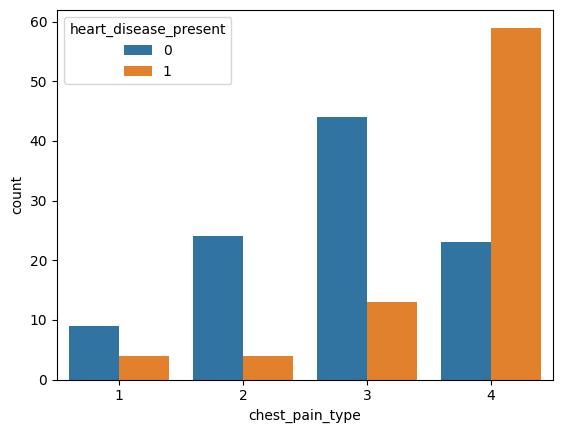

In [59]:
sns.countplot(x='chest_pain_type', hue='heart_disease_present', data=df)
plt.show()


**Chest pain type 4 has the most heart disease cases.**

**Type 3 has moderate disease cases.**

**Types 1 and 2 have very few disease cases.**

**Higher chest pain type → higher heart disease risk.**

**Exercise Induced Angina vs Heart Disease**

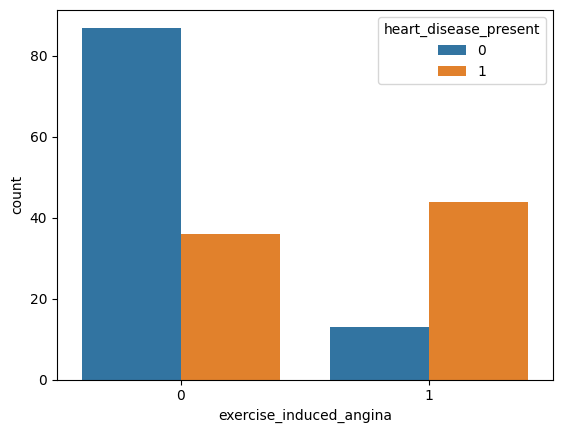

In [60]:
sns.countplot(x='exercise_induced_angina', hue='heart_disease_present', data=df)
plt.show()


**EIA = 0 (No angina): Mostly no heart disease.**

**EIA = 1 (Angina present): Mostly have heart disease.**

 **Presence of exercise-induced angina → high risk of heart disease.**

**handling outliers**

In [61]:
columns = [
    'age',
    'resting_blood_pressure',
    'serum_cholesterol_mg_per_dl',
    'max_heart_rate_achieved',
    'oldpeak_eq_st_depression'
]


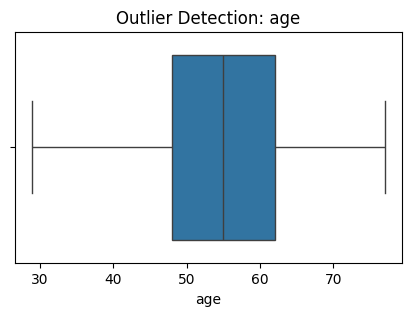

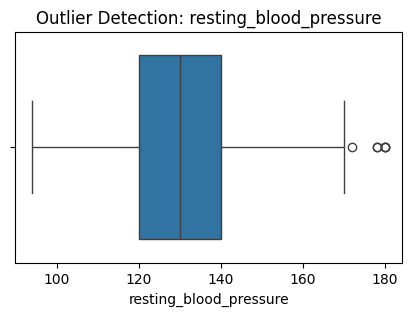

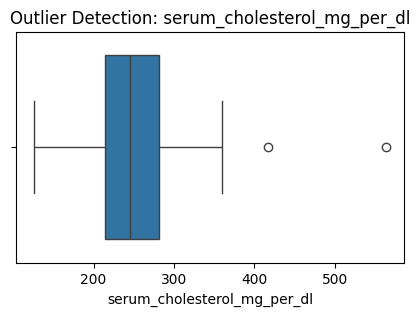

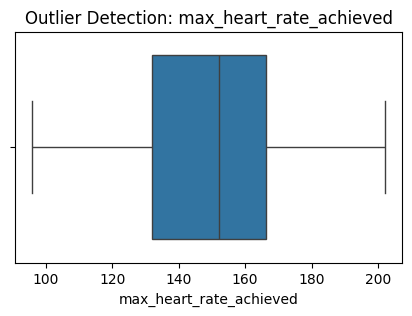

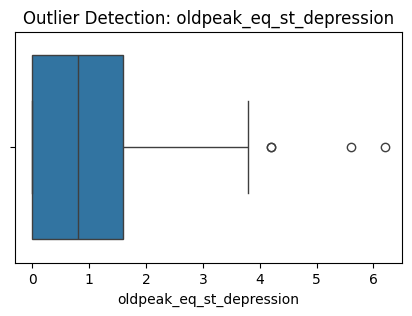

In [62]:
for col in columns:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(f'Outlier Detection: {col}')
    plt.show()


**Resting Blood Pressure**

Normal: 110–150

High outliers: 170–180

Cap only upper outliers

In [63]:
Q1 = df['resting_blood_pressure'].quantile(0.25)
Q3 = df['resting_blood_pressure'].quantile(0.75)
IQR = Q3 - Q1

upper_limit = Q3 + 1.5 * IQR

df['resting_blood_pressure'] = df['resting_blood_pressure'].clip(upper=upper_limit)


**Oldpeak (ST Depression)**

Observation:

Majority: 0–2

Outliers: 4–6 (right-skewed)

In [64]:
Q1 = df['oldpeak_eq_st_depression'].quantile(0.25)
Q3 = df['oldpeak_eq_st_depression'].quantile(0.75)
IQR = Q3 - Q1

upper_limit = Q3 + 1.5 * IQR

df['oldpeak_eq_st_depression'] = df['oldpeak_eq_st_depression'].clip(upper=upper_limit)


**serum_cholesterol_mg_per_dl**

**outliers : 420 - 600**

In [65]:
Q1 = df['serum_cholesterol_mg_per_dl'].quantile(0.25)
Q3 = df['serum_cholesterol_mg_per_dl'].quantile(0.75)
IQR = Q3 - Q1

upper_limit = Q3 + 1.5 * IQR

df['serum_cholesterol_mg_per_dl'] = df['serum_cholesterol_mg_per_dl'].clip(upper=upper_limit)


**Task 2: Model Building & Prediction**

   **Data Preprocessing**

In [66]:
df = df.drop('patient_id', axis=1)

In [67]:
X = df.drop('heart_disease_present', axis=1)
y = df['heart_disease_present']

**Label Encoding**

In [68]:
from sklearn.preprocessing import LabelEncoder  #Ordinal categorical
le = LabelEncoder()
X['thal'] = le.fit_transform(X['thal'])


**One-Hot Encoding**

In [69]:
X = pd.get_dummies(X, columns=['chest_pain_type'], drop_first=True) #Nominal categorical

**Correlation Matrix**

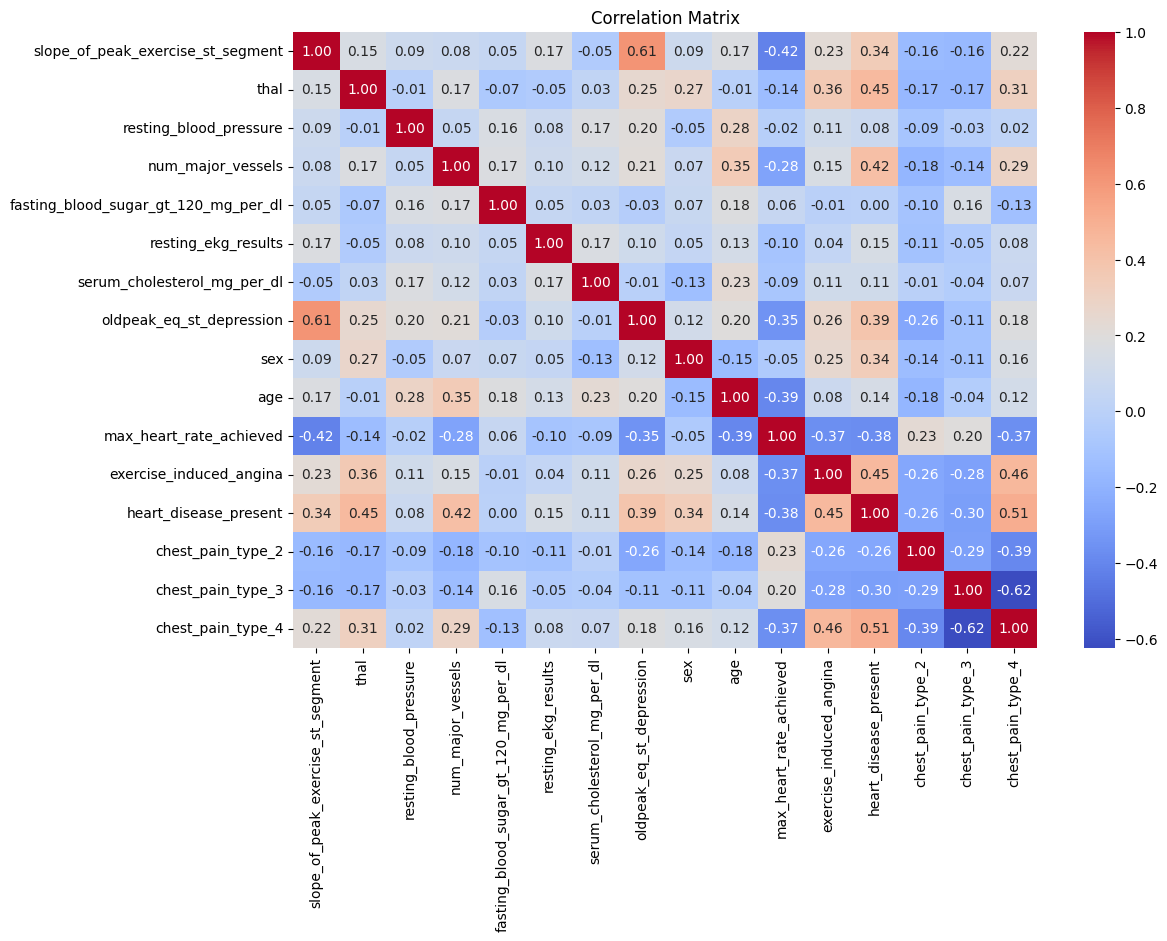

In [70]:
df_corr = df.copy()
le = LabelEncoder()
df_corr['thal'] = le.fit_transform(df_corr['thal'])
df_corr = pd.get_dummies(df_corr, columns=['chest_pain_type'], drop_first=True)

plt.figure(figsize=(12,8))
sns.heatmap(df_corr.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

**Top Positive Predictors:**

thal, exercise_induced_angina, num_major_vessels, chest_pain_type, oldpeak_eq_st_depression → strong indicators of heart disease.

**Moderate Predictors:**

slope_of_peak_exercise_st_segment, sex → moderately important.

**Protective Feature:**

max_heart_rate_achieved → higher values reduce risk.

**Weak Predictors:**

age, cholesterol, resting_blood_pressure, fasting_blood_sugar_gt_120_mg_per_dl → lower correlation, but may still help in combination with others.

**Split Data**

In [71]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Handle Class Imbalance**

In [72]:
from imblearn.over_sampling import SMOTE

print("Before SMOTE:\n", y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("After SMOTE:\n", y_train_res.value_counts())

Before SMOTE:
 heart_disease_present
0    84
1    60
Name: count, dtype: int64
After SMOTE:
 heart_disease_present
1    84
0    84
Name: count, dtype: int64


**Feature Scaling**

In [73]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

**Define Evaluation Function**

In [74]:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    if hasattr(model,"predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
    else:
        y_prob = model.decision_function(X_test)
    print(f"--- {name} ---")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))
    print('-'*50)
    return accuracy_score(y_test, y_pred), roc_auc_score(y_test, y_prob)

**Model Traing Before Tuning**

**Logistic Regression**

In [75]:
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)


In [76]:
lr = LogisticRegression()
lr.fit(X_train_scaled, y_train_res)
acc_lr_before, roc_lr_before = evaluate_model("Logistic Regression", lr, X_test_scaled, y_test)


--- Logistic Regression ---
Accuracy: 0.8611111111111112
ROC-AUC: 0.8875
Confusion Matrix:
 [[15  1]
 [ 4 16]]
Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.94      0.86        16
           1       0.94      0.80      0.86        20

    accuracy                           0.86        36
   macro avg       0.87      0.87      0.86        36
weighted avg       0.87      0.86      0.86        36

--------------------------------------------------


**Decision Tree**

In [77]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_scaled, y_train_res)
acc_dt_before, roc_dt_before = evaluate_model("Decision Tree", dt, X_test_scaled, y_test)


--- Decision Tree ---
Accuracy: 0.75
ROC-AUC: 0.7625
Confusion Matrix:
 [[14  2]
 [ 7 13]]
Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.88      0.76        16
           1       0.87      0.65      0.74        20

    accuracy                           0.75        36
   macro avg       0.77      0.76      0.75        36
weighted avg       0.78      0.75      0.75        36

--------------------------------------------------


**Random Forest**

In [78]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_scaled, y_train_res)
acc_rf_before, roc_rf_before = evaluate_model("Random Forest", rf, X_test_scaled, y_test)


--- Random Forest ---
Accuracy: 0.8611111111111112
ROC-AUC: 0.8843749999999999
Confusion Matrix:
 [[16  0]
 [ 5 15]]
Classification Report:
               precision    recall  f1-score   support

           0       0.76      1.00      0.86        16
           1       1.00      0.75      0.86        20

    accuracy                           0.86        36
   macro avg       0.88      0.88      0.86        36
weighted avg       0.89      0.86      0.86        36

--------------------------------------------------


**KNN**

In [79]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train_res)
acc_knn_before, roc_knn_before = evaluate_model("KNN", knn, X_test_scaled, y_test)


--- KNN ---
Accuracy: 0.8333333333333334
ROC-AUC: 0.85625
Confusion Matrix:
 [[15  1]
 [ 5 15]]
Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.94      0.83        16
           1       0.94      0.75      0.83        20

    accuracy                           0.83        36
   macro avg       0.84      0.84      0.83        36
weighted avg       0.85      0.83      0.83        36

--------------------------------------------------


**SVM**

In [80]:
svm = SVC(probability=True, random_state=42)
svm.fit(X_train_scaled, y_train_res)
acc_svm_before, roc_svm_before = evaluate_model("SVM", svm, X_test_scaled, y_test)


--- SVM ---
Accuracy: 0.8611111111111112
ROC-AUC: 0.875
Confusion Matrix:
 [[16  0]
 [ 5 15]]
Classification Report:
               precision    recall  f1-score   support

           0       0.76      1.00      0.86        16
           1       1.00      0.75      0.86        20

    accuracy                           0.86        36
   macro avg       0.88      0.88      0.86        36
weighted avg       0.89      0.86      0.86        36

--------------------------------------------------


**XGBoost**

In [81]:
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb.fit(X_train_scaled, y_train_res)
acc_xgb_before, roc_xgb_before = evaluate_model("XGBoost", xgb, X_test_scaled, y_test)


--- XGBoost ---
Accuracy: 0.8333333333333334
ROC-AUC: 0.8625
Confusion Matrix:
 [[15  1]
 [ 5 15]]
Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.94      0.83        16
           1       0.94      0.75      0.83        20

    accuracy                           0.83        36
   macro avg       0.84      0.84      0.83        36
weighted avg       0.85      0.83      0.83        36

--------------------------------------------------


**HYPERPARAMETER TUNING**

**Logistic Regression**

In [82]:
param_lr = {'C':[0.01,0.1,1,10,100],'solver':['liblinear','lbfgs']}
grid_lr = GridSearchCV(LogisticRegression(), param_lr, cv=5, scoring='roc_auc', n_jobs=-1)
grid_lr.fit(X_train_scaled, y_train_res)
best_lr = grid_lr.best_estimator_
acc_lr_after, roc_lr_after = evaluate_model("Logistic Regression", best_lr, X_test_scaled, y_test)


--- Logistic Regression ---
Accuracy: 0.8888888888888888
ROC-AUC: 0.9031250000000001
Confusion Matrix:
 [[16  0]
 [ 4 16]]
Classification Report:
               precision    recall  f1-score   support

           0       0.80      1.00      0.89        16
           1       1.00      0.80      0.89        20

    accuracy                           0.89        36
   macro avg       0.90      0.90      0.89        36
weighted avg       0.91      0.89      0.89        36

--------------------------------------------------


**Decision Tree**

In [83]:
param_dt = {'max_depth':[None,3,5,7,10],'min_samples_split':[2,5,10],'min_samples_leaf':[1,2,4],'criterion':['gini','entropy']}
grid_dt = GridSearchCV(DecisionTreeClassifier(random_state=42), param_dt, cv=5, scoring='roc_auc', n_jobs=-1)
grid_dt.fit(X_train_scaled, y_train_res)
best_dt = grid_dt.best_estimator_
acc_dt_after, roc_dt_after = evaluate_model("Decision Tree", best_dt, X_test_scaled, y_test)


--- Decision Tree ---
Accuracy: 0.6944444444444444
ROC-AUC: 0.796875
Confusion Matrix:
 [[12  4]
 [ 7 13]]
Classification Report:
               precision    recall  f1-score   support

           0       0.63      0.75      0.69        16
           1       0.76      0.65      0.70        20

    accuracy                           0.69        36
   macro avg       0.70      0.70      0.69        36
weighted avg       0.71      0.69      0.70        36

--------------------------------------------------


**Random Forest**

In [84]:
param_rf = {'n_estimators':[50,100,150],'max_depth':[None,3,5,7],'min_samples_split':[2,5,10],
            'min_samples_leaf':[1,2,4],'bootstrap':[True,False]}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_rf, cv=5, scoring='roc_auc', n_jobs=-1)
grid_rf.fit(X_train_scaled, y_train_res)
best_rf = grid_rf.best_estimator_
acc_rf_after, roc_rf_after = evaluate_model("Random Forest", best_rf, X_test_scaled, y_test)

--- Random Forest ---
Accuracy: 0.8611111111111112
ROC-AUC: 0.9
Confusion Matrix:
 [[16  0]
 [ 5 15]]
Classification Report:
               precision    recall  f1-score   support

           0       0.76      1.00      0.86        16
           1       1.00      0.75      0.86        20

    accuracy                           0.86        36
   macro avg       0.88      0.88      0.86        36
weighted avg       0.89      0.86      0.86        36

--------------------------------------------------


**KNN**

In [85]:
param_knn = {'n_neighbors':[3,5,7,9],'weights':['uniform','distance'],'p':[1,2]}
grid_knn = GridSearchCV(KNeighborsClassifier(), param_knn, cv=5, scoring='roc_auc', n_jobs=-1)
grid_knn.fit(X_train_scaled, y_train_res)
best_knn = grid_knn.best_estimator_
acc_knn_after, roc_knn_after = evaluate_model("KNN", best_knn, X_test_scaled, y_test)


--- KNN ---
Accuracy: 0.8611111111111112
ROC-AUC: 0.875
Confusion Matrix:
 [[16  0]
 [ 5 15]]
Classification Report:
               precision    recall  f1-score   support

           0       0.76      1.00      0.86        16
           1       1.00      0.75      0.86        20

    accuracy                           0.86        36
   macro avg       0.88      0.88      0.86        36
weighted avg       0.89      0.86      0.86        36

--------------------------------------------------


**SVM**

In [86]:
param_svm = {'C':[0.1,1,10,100],'kernel':['linear','rbf','poly'],'gamma':['scale','auto']}
grid_svm = GridSearchCV(SVC(probability=True, random_state=42), param_svm, cv=5, scoring='roc_auc', n_jobs=-1)
grid_svm.fit(X_train_scaled, y_train_res)
best_svm = grid_svm.best_estimator_
acc_svm_after, roc_svm_after = evaluate_model("SVM", best_svm, X_test_scaled, y_test)


--- SVM ---
Accuracy: 0.8333333333333334
ROC-AUC: 0.8468749999999999
Confusion Matrix:
 [[15  1]
 [ 5 15]]
Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.94      0.83        16
           1       0.94      0.75      0.83        20

    accuracy                           0.83        36
   macro avg       0.84      0.84      0.83        36
weighted avg       0.85      0.83      0.83        36

--------------------------------------------------


**XGBoost**

In [87]:
param_xgb = {'n_estimators':[50,100,150],'max_depth':[3,4,5],'learning_rate':[0.05,0.1,0.2],
             'subsample':[0.8,1.0],'colsample_bytree':[0.8,1.0]}
grid_xgb = GridSearchCV(XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
                        param_xgb, cv=5, scoring='roc_auc', n_jobs=-1)
grid_xgb.fit(X_train_scaled, y_train_res)
best_xgb = grid_xgb.best_estimator_
acc_xgb_after, roc_xgb_after = evaluate_model("XGBoost", best_xgb, X_test_scaled, y_test)


--- XGBoost ---
Accuracy: 0.8333333333333334
ROC-AUC: 0.85625
Confusion Matrix:
 [[15  1]
 [ 5 15]]
Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.94      0.83        16
           1       0.94      0.75      0.83        20

    accuracy                           0.83        36
   macro avg       0.84      0.84      0.83        36
weighted avg       0.85      0.83      0.83        36

--------------------------------------------------


**MODEL COMPARISON TABLE**

In [88]:
comparison_full = pd.DataFrame({
    'Model': ['Logistic Regression','Decision Tree','Random Forest','KNN','SVM','XGBoost'],
    'Accuracy Before': [acc_lr_before, acc_dt_before, acc_rf_before, acc_knn_before, acc_svm_before, acc_xgb_before],
    'ROC-AUC Before': [roc_lr_before, roc_dt_before, roc_rf_before, roc_knn_before, roc_svm_before, roc_xgb_before],
    'Accuracy After': [acc_lr_after, acc_dt_after, acc_rf_after, acc_knn_after, acc_svm_after, acc_xgb_after],
    'ROC-AUC After': [roc_lr_after, roc_dt_after, roc_rf_after, roc_knn_after, roc_svm_after, roc_xgb_after]
})

print("\n--- Model Comparison: Before vs After Hyperparameter Tuning ---")
print(comparison_full)


--- Model Comparison: Before vs After Hyperparameter Tuning ---
                 Model  Accuracy Before  ROC-AUC Before  Accuracy After  \
0  Logistic Regression         0.861111        0.887500        0.888889   
1        Decision Tree         0.750000        0.762500        0.694444   
2        Random Forest         0.861111        0.884375        0.861111   
3                  KNN         0.833333        0.856250        0.861111   
4                  SVM         0.861111        0.875000        0.833333   
5              XGBoost         0.833333        0.862500        0.833333   

   ROC-AUC After  
0       0.903125  
1       0.796875  
2       0.900000  
3       0.875000  
4       0.846875  
5       0.856250  


**After tuning:**

**Higher accuracy → 0.889 vs 0.861**

**Higher ROC-AUC → 0.903 vs 0.888**

**Better at distinguishing patients with and without heart disease.**

so for deployment, always use the tuned Logistic Regression model

**Save Model**

In [92]:
import pickle

# Save tuned Logistic Regression model
pickle.dump(best_lr, open('tuned_logistic_regression.pkl', 'wb'))

# Save scaler (very important for deployment)
pickle.dump(scaler, open('scaler.pkl', 'wb'))

print("Model and scaler saved successfully!")


Model and scaler saved successfully!


In [93]:
pickle.dump(X.columns.tolist(), open("model_features.pkl", "wb"))


**GUI**

In [96]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import pandas as pd
import pickle

# ================= LOAD SAVED OBJECTS =================
model = pickle.load(open("tuned_logistic_regression.pkl", "rb"))
scaler = pickle.load(open("scaler.pkl", "rb"))
model_features = pickle.load(open("model_features.pkl", "rb"))

# ================= INPUT WIDGETS =================
age = widgets.IntSlider(value=50, min=20, max=90, step=1, description="Age")

sex = widgets.Dropdown(
    options=[("Female", 0), ("Male", 1)],
    value=1,
    description="Sex"
)

resting_bp = widgets.IntSlider(
    value=120, min=80, max=200, step=1, description="Rest BP"
)

chol = widgets.IntSlider(
    value=200, min=100, max=600, step=1, description="Cholesterol"
)

max_hr = widgets.IntSlider(
    value=150, min=70, max=210, step=1, description="Max HR"
)

oldpeak = widgets.FloatSlider(
    value=1.0, min=0.0, max=6.0, step=0.1, description="Oldpeak"
)

num_vessels = widgets.IntSlider(
    value=0, min=0, max=3, step=1, description="Major Vessels"
)

exang = widgets.Dropdown(
    options=[("No", 0), ("Yes", 1)],
    value=0,
    description="Ex Angina"
)

fbs = widgets.Dropdown(
    options=[("No", 0), ("Yes", 1)],
    value=0,
    description="FBS >120"
)

restecg = widgets.Dropdown(
    options=[("Normal", 0), ("ST-T abnormality", 1), ("LV hypertrophy", 2)],
    value=0,
    description="Rest ECG"
)

slope = widgets.Dropdown(
    options=[("Upsloping", 1), ("Flat", 2), ("Downsloping", 3)],
    value=2,
    description="Slope"
)

thal = widgets.Dropdown(
    options=[("Normal", 0), ("Fixed Defect", 1), ("Reversible Defect", 2)],
    value=1,
    description="Thal"
)

cp = widgets.Dropdown(
    options=[("Type 1", 1), ("Type 2", 2), ("Type 3", 3), ("Type 4", 4)],
    value=3,
    description="Chest Pain"
)

# ================= BUTTON & OUTPUT =================
predict_btn = widgets.Button(description="Predict", button_style="success")
output = widgets.Output()

# ================= PREDICTION FUNCTION =================
def predict(b):
    with output:
        clear_output()

        # Create input with EXACT training column names
        input_df = pd.DataFrame([{
            'age': age.value,
            'sex': sex.value,
            'resting_blood_pressure': resting_bp.value,
            'serum_cholesterol_mg_per_dl': chol.value,
            'max_heart_rate_achieved': max_hr.value,
            'oldpeak_eq_st_depression': oldpeak.value,
            'num_major_vessels': num_vessels.value,
            'exercise_induced_angina': exang.value,
            'fasting_blood_sugar_gt_120_mg_per_dl': fbs.value,
            'resting_ekg_results': restecg.value,
            'slope_of_peak_exercise_st_segment': slope.value,
            'thal': thal.value,
            'chest_pain_type': cp.value
        }])

        # One-hot encode chest pain (same as training)
        input_df = pd.get_dummies(
            input_df,
            columns=['chest_pain_type'],
            drop_first=True
        )

        # Align columns with training features
        for col in model_features:
            if col not in input_df.columns:
                input_df[col] = 0
        input_df = input_df[model_features]

        # Scale
        input_scaled = scaler.transform(input_df)

        # Predict
        prob = model.predict_proba(input_scaled)[0][1]
        pred = model.predict(input_scaled)[0]

        # Risk level
        if prob < 0.3:
            risk = "LOW"
        elif prob < 0.7:
            risk = "MEDIUM"
        else:
            risk = "HIGH"

        print("Heart Disease Prediction:", "YES" if pred == 1 else "NO")
        print(f"Probability: {prob:.2f}")
        print("Risk Level:", risk)

# ================= CONNECT & DISPLAY =================
predict_btn.on_click(predict)

display(widgets.VBox([
    age, sex, cp,
    resting_bp, chol, max_hr,
    exang, fbs, restecg,
    slope, num_vessels, thal,
    oldpeak,
    predict_btn,
    output
]))


# Task 3 – Hospital Recommendations

## **1. Early Screening**

Focus on patients who have high-risk signs, such as:

* Chest pain during exercise (exercise-induced angina)

* Abnormal blood flow in the heart (thal defects)

* More than 1 major blocked vessel (num_major_vessels > 1)

* High stress on the heart during exercise (high oldpeak)

* These patients should be checked first to prevent serious heart problems.

## **2. Preventive Measures**

* Encourage regular checkups for men over 45 years.

* Monitor and manage:
    
   * Blood pressure

   * Cholesterol

   * Blood sugar

* Promote healthy lifestyle habits like exercise, diet, and stress reduction.

## **3. Using ML Model in Hospitals**

* Use the trained Logistic Regression model to assess heart disease risk.

* Doctors can input patient data using the GUI app to get:

    * Heart disease prediction (Yes/No)

    * Risk level: Low, Medium, or High

* This helps doctors make faster, informed decisions.

## **4. Medical Intervention Alerts**

* Patients identified as High Risk should get immediate tests like:

   * ECG (heart tracing)

   * Stress test

* Early intervention can prevent life-threatening events.